# Would AI Discover Ophiuchus?

A clustering-based analysis of stellar structure in the Ophiuchus region using Gaia DR3 data.

## Abstract

This notebook investigates whether a human-defined constellation pattern can be recovered from stellar positional data using unsupervised machine learning methods.
Ophiuchus is used as a case study because it has an irregular visual geometry and represents a useful example for comparing human symbolic interpretation with machine-based clustering.
The analysis uses Gaia DR3 stellar data, projects celestial coordinates into Cartesian space, and applies DBSCAN and Spectral Clustering to explore possible statistical groupings.

## 1. Human-defined view of Ophiuchus

The following image shows the traditional human-defined representation of the Ophiuchus constellation as visualized in Stellarium.

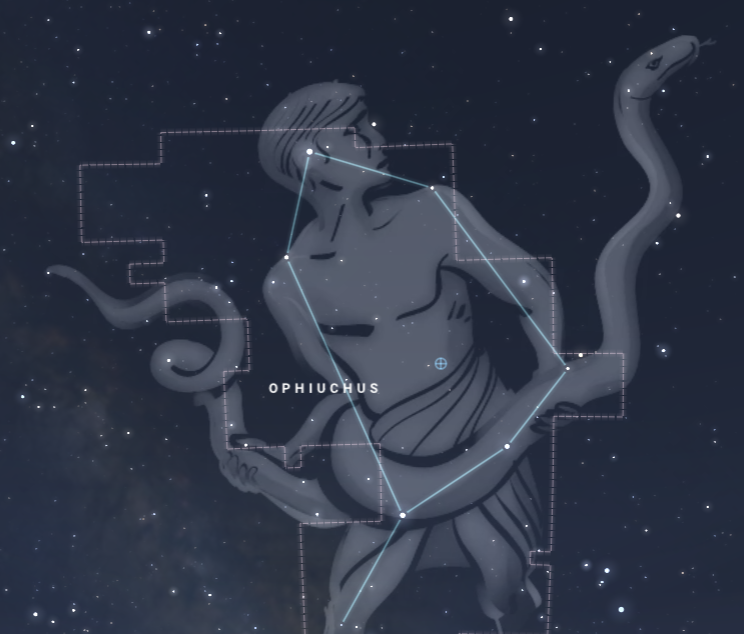

In [55]:
from IPython.display import Image, display

display(Image(filename="figures/figure0_ophiuchus_human.png"))

**Figure 1.** Human interpretation of the Ophiuchus constellation as visualized in Stellarium. The constellation artwork and connecting lines are overlaid on the stellar background, illustrating a culturally defined pattern rather than a physically bound stellar structure.

In [56]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN, SpectralClustering
from astropy.coordinates import SkyCoord
import astropy.units as u

In [57]:
!pip install astroquery

In [58]:
from astroquery.gaia import Gaia

query = """
SELECT TOP 2000
ra, dec, parallax, phot_g_mean_mag
FROM gaiadr3.gaia_source
WHERE ra BETWEEN 240 AND 270
AND dec BETWEEN -30 AND +10
AND phot_g_mean_mag IS NOT NULL
"""

job = Gaia.launch_job_async(query)
data = job.get_results()

ra = np.array(data["ra"])
dec = np.array(data["dec"])
mag = np.array(data["phot_g_mean_mag"])

print(data[:5])
print("Number of stars:", len(data))

INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]
        ra                 dec                parallax       phot_g_mean_mag
       deg                 deg                  mas                mag      
------------------ ------------------- --------------------- ---------------
243.38159586435162 -29.996606416298008  -0.18437786253519367       19.599789
243.42917503379397  -29.97297498609702   0.09345114627760415       19.284334
 243.4103211765052 -29.977001786194503 -0.007623511183783391       18.701883
243.41931964797092  -29.96975806456069  -0.22981845292876515       19.600164
243.35227246501418  -29.98440420081918   0.19613903765598936        16.28127
Number of stars: 2000


In [59]:
coord = SkyCoord(ra=ra*u.degree, dec=dec*u.degree, frame="icrs")

x = coord.cartesian.x.value
y = coord.cartesian.y.value
z = coord.cartesian.z.value

X = np.vstack([x, y, z]).T

print("Shape of feature matrix:", X.shape)

Shape of feature matrix: (2000, 3)


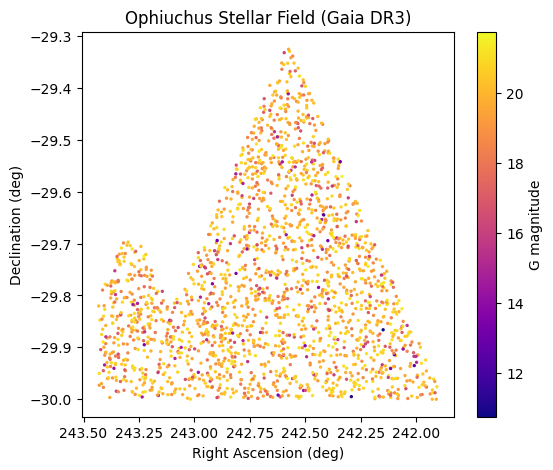

In [60]:
!mkdir -p figures

plt.figure(figsize=(6, 5))
plt.scatter(ra, dec, s=2, c=mag, cmap="plasma")
plt.gca().invert_xaxis()
plt.title("Ophiuchus Stellar Field (Gaia DR3)")
plt.xlabel("Right Ascension (deg)")
plt.ylabel("Declination (deg)")
plt.colorbar(label="G magnitude")

plt.savefig("figures/figure1_gaia_field.png", dpi=300, bbox_inches="tight")
plt.show()

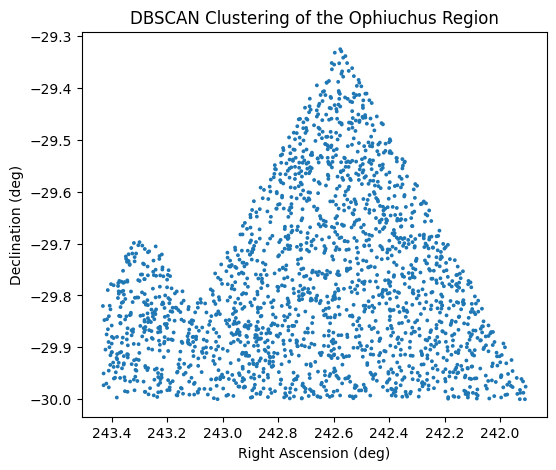

DBSCAN labels: [0]


In [61]:
db = DBSCAN(eps=0.05, min_samples=5)
labels_db = db.fit_predict(X)

plt.figure(figsize=(6, 5))
plt.scatter(ra, dec, c=labels_db, s=3, cmap="tab10")
plt.gca().invert_xaxis()
plt.title("DBSCAN Clustering of the Ophiuchus Region")
plt.xlabel("Right Ascension (deg)")
plt.ylabel("Declination (deg)")

plt.savefig("figures/figure2_dbscan.png", dpi=300, bbox_inches="tight")
plt.show()

print("DBSCAN labels:", np.unique(labels_db))

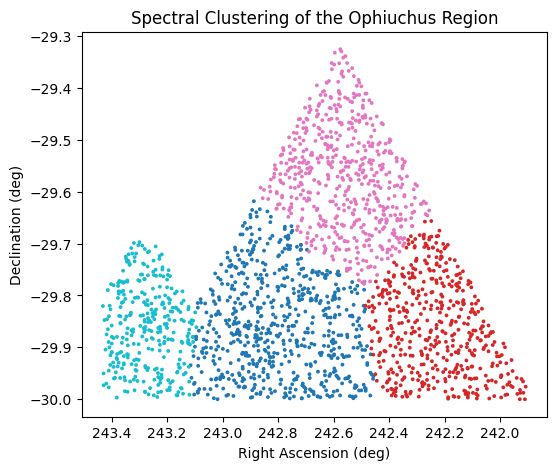

In [62]:
sc = SpectralClustering(
    n_clusters=4,
    affinity="nearest_neighbors",
    n_neighbors=10,
    random_state=42
)

labels_sc = sc.fit_predict(X)

plt.figure(figsize=(6, 5))
plt.scatter(ra, dec, c=labels_sc, s=3, cmap="tab10")
plt.gca().invert_xaxis()
plt.title("Spectral Clustering of the Ophiuchus Region")
plt.xlabel("Right Ascension (deg)")
plt.ylabel("Declination (deg)")

plt.savefig("figures/figure3_spectral.png", dpi=300, bbox_inches="tight")
plt.show()

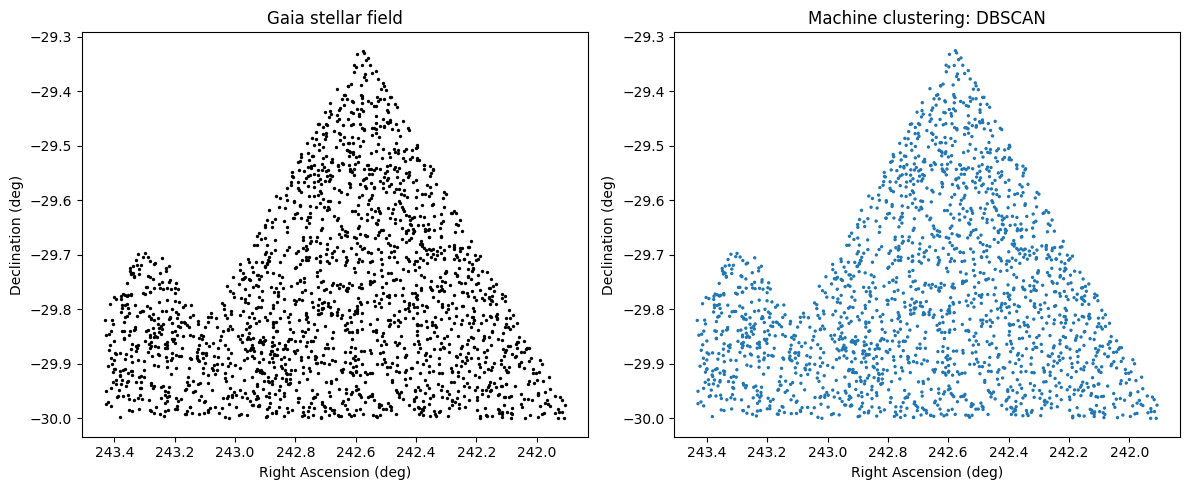

In [63]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(ra, dec, s=2, c="black")
ax[0].invert_xaxis()
ax[0].set_title("Gaia stellar field")
ax[0].set_xlabel("Right Ascension (deg)")
ax[0].set_ylabel("Declination (deg)")

ax[1].scatter(ra, dec, s=2, c=labels_db, cmap="tab10")
ax[1].invert_xaxis()
ax[1].set_title("Machine clustering: DBSCAN")
ax[1].set_xlabel("Right Ascension (deg)")
ax[1].set_ylabel("Declination (deg)")

plt.tight_layout()
plt.savefig("figures/figure4_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## Discussion and Conclusion

The results highlight the difference between human-defined constellations and machine-based statistical grouping.
The traditional constellation of Ophiuchus is a cultural and historical pattern imposed on the night sky. It is based on visual interpretation rather than on a physically bound stellar system.
In contrast, machine learning algorithms such as DBSCAN and Spectral Clustering group stars according to numerical spatial features. These methods may identify local density patterns or statistical structures, but they do not necessarily reproduce the symbolic shape of the constellation.
Therefore, an artificial intelligence system would not automatically "discover" Ophiuchus in the same way humans define it. Instead, it would detect computational patterns in the stellar distribution.